6) For each drug in the database, provide the number of pathways it interacts with. Present the results as a histogram with appropriately labeled axes.

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd

# Define the file path and namespace
file_path = 'drugbank_partial.xml'
namespace = {'drugbank': 'http://www.drugbank.ca'}
data = []
depth = 0

# Parse the XML file and extract relevant information
for event, elem in ET.iterparse(file_path, events=('start', 'end')):
    if event == 'start':
        depth += 1
    elif event == 'end':
        depth -= 1

    # Process each drug element when the end tag is encountered
    if elem.tag == f"{{{namespace['drugbank']}}}drug" and event == 'end' and depth == 1:
        drugbank_id_elem = elem.find('drugbank:drugbank-id[@primary="true"]', namespace)
        drugbank_id = drugbank_id_elem.text
        # Count the number of pathways associated with the drug
        pathways_count = len(elem.findall('.//drugbank:pathway', namespace))
        data.append({'drugbank-id': drugbank_id, 'pathways_count': pathways_count})
        elem.clear()

# Create a DataFrame from the extracted data
df = pd.DataFrame(data)
df

,drugbank-id,pathways_count
0,DB00001,1
1,DB00002,1
2,DB00003,0
3,DB00004,0
4,DB00005,0
...,...,...
95,DB00104,0
96,DB00105,0
97,DB00106,0
98,DB00107,0


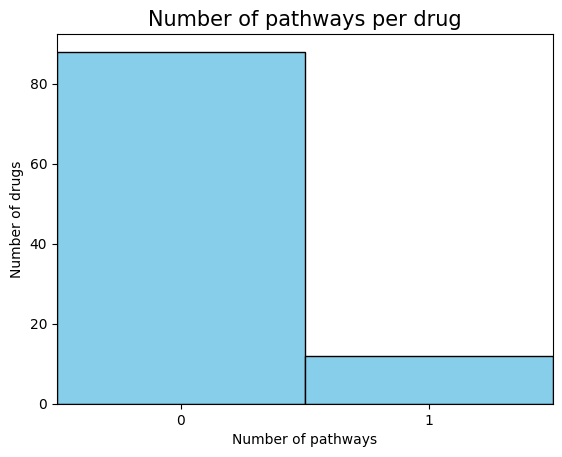

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Plot a histogram of the number of pathways per drug
plt.hist(df['pathways_count'], bins=[-0.5, 0.5, 1.5], color='skyblue', edgecolor='black')
plt.title('Number of pathways per drug', fontsize=15)
plt.xlabel('Number of pathways')
plt.ylabel('Number of drugs')

plt.xticks(np.arange(min(df['pathways_count']), max(df['pathways_count']) + 1, 1))
plt.xlim(-0.5, max(df['pathways_count']) + 0.5)

plt.show()